# Week 4: Importing and Exploring Data - Class Exercises

We first load the packages necessary for this exercise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import requests

---

## 1. International Visitor Arrivals in Singapore

The file `tourist.csv` (available from `Canvas > Files > data`) contains monthly international visitor arrivals by length of stay from July to December in 2023, 
retrieved from the Singapore Department of Statistics. 

Let’s start by reading in the data as `df` with the standard relative path.

In [2]:
df = pd.read_csv('../data/tourist.csv')

**(A) Data Cleaning**

Examine the dataframe carefully. 

Some of the categories in the column `Data Series` are overlapping. Remove the redundant entry. 

Store the cleaned data frame as `df2`.

(**Hint**: Use `copy()` to create a new independent copy of the cleaned data frame. It makes sure we are not accidentally making changes to the original data frame. Read more [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.copy.html).)

In [3]:
# Type your code here:
df2 = df[df['Data Series'] != '15 Days & Over'].copy()
df2

,Data Series,2023 Dec,2023 Nov,2023 Oct,2023 Sep,2023 Aug,2023 Jul
0,Under 1 Day,259568,240351,236035,227788,248805,269994
1,1 Day,189997,181139,175731,166190,190444,202319
2,2 Days,162209,177977,181721,167772,197076,205910
3,3 Days,168788,168898,189215,172901,210238,216598
4,4 Days,117981,105229,126509,114319,162079,160111
5,5 Days,64785,56366,69110,62421,98284,98065
6,6 Days,38500,31919,37922,37647,52957,58609
7,7 Days,25082,21058,24014,25955,32983,37887
8,8-10 Days,31446,26251,29618,29818,39565,43611
9,11-14 Days,19370,15348,16519,16837,24048,25987


In [4]:
df2['Data Series'].nunique()

13

**[Fill in the blank]** After cleaning the data, there are 13 non-overlapping categories in `Data Series`.

**(B) Summary Statistics**

The total number of international visitors in December 2023 was 1,113,842 .

In [5]:
# Type your code here:
df2['2023 Dec'] = pd.to_numeric(df2['2023 Dec'])
df['2023 Dec'].sum()

np.int64(1149958)

In [6]:
f"{df2['2023 Dec'].sum():,}"


'1,113,842'

**(C) Barplot**

Re-create, as much as you can, the horizontal bar chart below showing the distribution of tourists’ length of stay in December 2023.

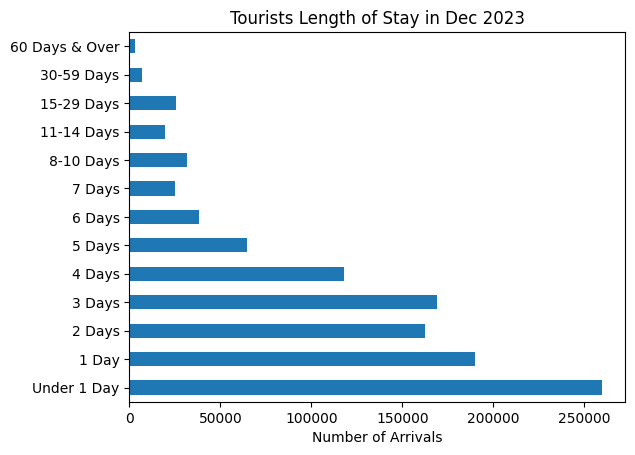

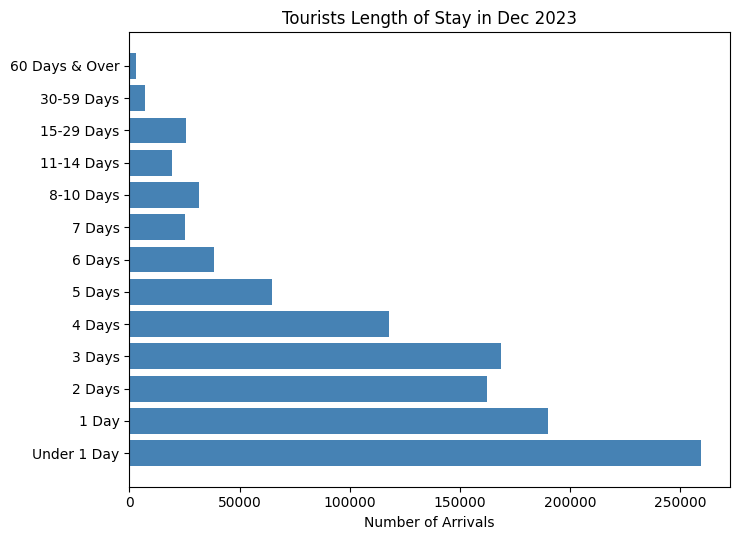

In [7]:
# Type your code here:
df['2023 Dec'] = pd.to_numeric(df2['2023 Dec'])

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(df2['Data Series'], df2['2023 Dec'], color='steelblue')

ax.set_title('Tourists Length of Stay in Dec 2023')
ax.set_xlabel('Number of Arrivals')

plt.tight_layout()
plt.show()

---

## 2. Pupil-Teacher Ratio

There are 5000+ data sets available on [data.gov.sg](https://data.gov.sg).

In this exercise, practice querying and visualizing data on the Pupil-Teacher Ratio (PTR) in primary schools by year. Try reproducing the plot below.

[https://data.gov.sg/datasets/d_bc5a1a10afedf7d25128dae1342c9556/view](https://data.gov.sg/datasets/d_bc5a1a10afedf7d25128dae1342c9556/view)

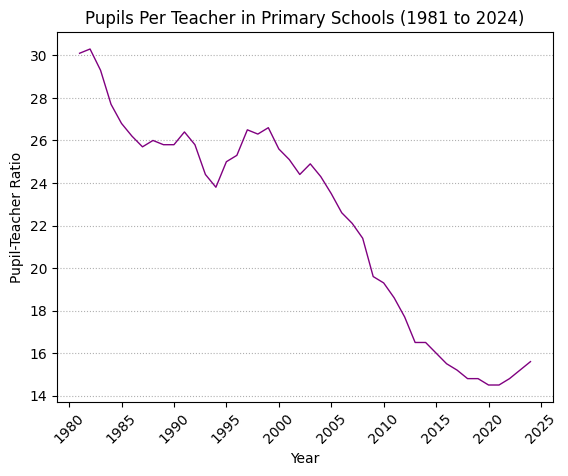

In [15]:
ptr = pd.read_csv('../data/PupilsPerTeacherinPrimarySchools.csv')


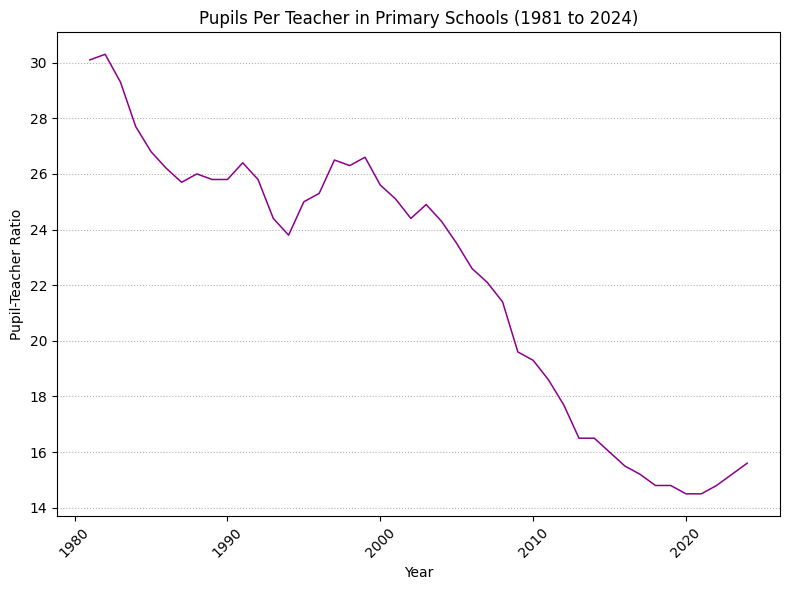

In [16]:
ptr['year'] = pd.to_numeric(ptr['year'])
ptr['pri_students_to_teachers'] = pd.to_numeric(ptr['pri_students_to_teachers'])
ptr = ptr.sort_values('year')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ptr['year'], ptr['pri_students_to_teachers'], color='darkmagenta', linewidth=1.1)

ax.set_title('Pupils Per Teacher in Primary Schools (1981 to 2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Pupil-Teacher Ratio')
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.6)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()